# CARS EDA PROJECT

## Importing the necessary libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


#### Load the Dataset

In [ ]:
df = pd.read_csv("Cars.csv")
df.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Colour,Seats,No. of Doors,New_Price,Price
0,Mahindra Scorpio,Pune,2012.0,99000.0,Diesel,Manual,Third,12.05 kmpl,2179 CC,120 bhp,Black/Silver,8.0,5.0,NaN,6.00
1,Maruti Baleno,Kochi,2018.0,18678.0,Petrol,Manual,First,21.1 kmpl,998 CC,100 bhp,Others,5.0,4.0,NaN,8.32
2,Mahindra Xylo,Bangalore,2013.0,197000.0,Diesel,Manual,First,11.68 kmpl,2498 CC,112 bhp,White,7.0,5.0,NaN,4.00
3,Hyundai Grand,Delhi,2014.0,45000.0,Diesel,Manual,First,24.0 kmpl,1120 CC,70 bhp,White,5.0,4.0,NaN,3.49
4,Toyota Innova,Delhi,2011.0,65000.0,Diesel,Manual,First,12.8 kmpl,2494 CC,102 bhp,Others,8.0,5.0,NaN,6.40


#### Check number of rows and columns

In [ ]:
df.shape

(5961, 15)

#### Get column names, data types, and null values

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5961 entries, 0 to 5960
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               5961 non-null   object 
 1   Location           5950 non-null   object 
 2   Year               5959 non-null   float64
 3   Kilometers_Driven  5953 non-null   float64
 4   Fuel_Type          5961 non-null   object 
 5   Transmission       5934 non-null   object 
 6   Owner_Type         5946 non-null   object 
 7   Mileage            5959 non-null   object 
 8   Engine             5944 non-null   object 
 9   Power              5929 non-null   object 
 10  Colour             5950 non-null   object 
 11  Seats              5956 non-null   float64
 12  No. of Doors       5960 non-null   float64
 13  New_Price          824 non-null    object 
 14  Price              5961 non-null   float64
dtypes: float64(5), object(10)
memory usage: 698.7+ KB


#### Statistical summary for numerical columns

In [ ]:
df.describe()

,Year,Kilometers_Driven,Seats,No. of Doors,Price
count,5959.000000,5.953000e+03,5956.000000,5960.000000,5961.000000
mean,2013.389159,5.871110e+04,5.269140,4.114933,9.528103
std,3.243051,9.171221e+04,0.789048,0.344757,11.214382
min,1998.000000,1.710000e+02,2.000000,2.000000,0.440000
25%,2011.500000,3.393100e+04,5.000000,4.000000,3.500000
50%,2014.000000,5.300000e+04,5.000000,4.000000,5.660000
75%,2016.000000,7.300000e+04,5.000000,4.000000,10.000000
max,2019.000000,6.500000e+06,10.000000,5.000000,160.000000


#### View all column names

In [ ]:
df.columns

Index(['Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type',
       'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Colour',
       'Seats', 'No. of Doors', 'New_Price', 'Price'],
      dtype='object')

#### Identify missing values in each column

In [ ]:
df.isnull().sum()

Name                    0
Location               11
Year                    2
Kilometers_Driven       8
Fuel_Type               0
Transmission           27
Owner_Type             15
Mileage                 2
Engine                 17
Power                  32
Colour                 11
Seats                   5
No. of Doors            1
New_Price            5137
Price                   0
dtype: int64

#### Identify duplicate rows in each column

In [ ]:
df.duplicated().sum()

np.int64(1)

#### Checking the correlation between the columns

In [ ]:
df.corr(numeric_only = True)

,Year,Kilometers_Driven,Seats,No. of Doors,Price
Year,1.000000,-0.172923,0.014357,0.018310,0.305501
Kilometers_Driven,-0.172923,1.000000,0.086881,0.068335,-0.011403
Seats,0.014357,0.086881,1.000000,0.905095,0.060332
No. of Doors,0.018310,0.068335,0.905095,1.000000,0.066697
Price,0.305501,-0.011403,0.060332,0.066697,1.000000


## Feature Engineering & Data Cleaning

* As we saw that there are more than 85% value in the new_price column are null.
* So,we are dropping new_price column from the df.

In [ ]:
df.drop(columns = ['New_Price'],inplace = True)
df.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Colour,Seats,No. of Doors,Price
0,Mahindra Scorpio,Pune,2012.0,99000.0,Diesel,Manual,Third,12.05 kmpl,2179 CC,120 bhp,Black/Silver,8.0,5.0,6.00
1,Maruti Baleno,Kochi,2018.0,18678.0,Petrol,Manual,First,21.1 kmpl,998 CC,100 bhp,Others,5.0,4.0,8.32
2,Mahindra Xylo,Bangalore,2013.0,197000.0,Diesel,Manual,First,11.68 kmpl,2498 CC,112 bhp,White,7.0,5.0,4.00
3,Hyundai Grand,Delhi,2014.0,45000.0,Diesel,Manual,First,24.0 kmpl,1120 CC,70 bhp,White,5.0,4.0,3.49
4,Toyota Innova,Delhi,2011.0,65000.0,Diesel,Manual,First,12.8 kmpl,2494 CC,102 bhp,Others,8.0,5.0,6.40


In [ ]:
df[df.duplicated()==True]

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Colour,Seats,No. of Doors,Price
5648,Maruti Alto,Hyderabad,2007.0,52195.0,Petrol,Manual,First,19.7 kmpl,796 CC,46.3 bhp,Others,5.0,4.0,1.75
5779,Maruti Baleno,Kolkata,2016.0,29000.0,Diesel,Manual,First,27.39 kmpl,1248 CC,74 bhp,Black/Silver,5.0,4.0,6.50


#### Drop the duplicate rows

In [ ]:
df.drop_duplicates(inplace = True)

In [ ]:
df.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Colour,Seats,No. of Doors,Price
0,Mahindra Scorpio,Pune,2012.0,99000.0,Diesel,Manual,Third,12.05 kmpl,2179 CC,120 bhp,Black/Silver,8.0,5.0,6.00
1,Maruti Baleno,Kochi,2018.0,18678.0,Petrol,Manual,First,21.1 kmpl,998 CC,100 bhp,Others,5.0,4.0,8.32
2,Mahindra Xylo,Bangalore,2013.0,197000.0,Diesel,Manual,First,11.68 kmpl,2498 CC,112 bhp,White,7.0,5.0,4.00
3,Hyundai Grand,Delhi,2014.0,45000.0,Diesel,Manual,First,24.0 kmpl,1120 CC,70 bhp,White,5.0,4.0,3.49
4,Toyota Innova,Delhi,2011.0,65000.0,Diesel,Manual,First,12.8 kmpl,2494 CC,102 bhp,Others,8.0,5.0,6.40


#### Split the 'Mileage' column into numeric value and unit (kmpl / kmkg) for better analysis

In [ ]:
df[['Mileage_value','Mileage_unit']] =df['Mileage'].str.split(" ",expand = True)
df[['Mileage_value','Mileage_unit']] 

,Mileage_value,Mileage_unit
0,12.05,kmpl
1,21.1,kmpl
2,11.68,kmpl
3,24.0,kmpl
4,12.8,kmpl
...,...,...
5956,13.9,kmpl
5957,18.5,kmpl
5958,20.4,kmpl
5959,18.1,kmpl


#### Split the 'Engine' column into numeric value and unit (CC)

In [ ]:
df[['Engine_value','Engine_unit']] = df['Engine'].str.split(" ", expand=True)
df[['Engine_value','Engine_unit']]

,Engine_value,Engine_unit
0,2179,CC
1,998,CC
2,2498,CC
3,1120,CC
4,2494,CC
...,...,...
5956,1799,CC
5957,1197,CC
5958,1197,CC
5959,3498,CC


#### Split the 'Power' column into numeric value and unit (bhp) 

In [ ]:

df[['Power_value','Power_unit']] = df['Power'].str.split(" ", expand=True)
df[['Power_value','Power_unit']]

,Power_value,Power_unit
0,120,bhp
1,100,bhp
2,112,bhp
3,70,bhp
4,102,bhp
...,...,...
5956,130.3,bhp
5957,82.9,bhp
5958,81.80,bhp
5959,306,bhp


#### Remove original columns after extracting numeric values and units

In [ ]:
df.drop(columns = ['Mileage', 'Engine', 'Power'],inplace = True)
df.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Colour,Seats,No. of Doors,Price,Mileage_value,Mileage_unit,Engine_value,Engine_unit,Power_value,Power_unit
0,Mahindra Scorpio,Pune,2012.0,99000.0,Diesel,Manual,Third,Black/Silver,8.0,5.0,6.00,12.05,kmpl,2179,CC,120,bhp
1,Maruti Baleno,Kochi,2018.0,18678.0,Petrol,Manual,First,Others,5.0,4.0,8.32,21.1,kmpl,998,CC,100,bhp
2,Mahindra Xylo,Bangalore,2013.0,197000.0,Diesel,Manual,First,White,7.0,5.0,4.00,11.68,kmpl,2498,CC,112,bhp
3,Hyundai Grand,Delhi,2014.0,45000.0,Diesel,Manual,First,White,5.0,4.0,3.49,24.0,kmpl,1120,CC,70,bhp
4,Toyota Innova,Delhi,2011.0,65000.0,Diesel,Manual,First,Others,8.0,5.0,6.40,12.8,kmpl,2494,CC,102,bhp


In [ ]:
df.dtypes

Name                  object
Location              object
Year                 float64
Kilometers_Driven    float64
Fuel_Type             object
Transmission          object
Owner_Type            object
Colour                object
Seats                float64
No. of Doors         float64
Price                float64
Mileage_value         object
Mileage_unit          object
Engine_value          object
Engine_unit           object
Power_value           object
Power_unit            object
dtype: object

#### Convert mileage, engine, and power values from object (string) to float

In [ ]:
df[['Mileage_value','Engine_value']] = df[['Mileage_value','Engine_value']].astype(float)

In [ ]:
df.dtypes

Name                  object
Location              object
Year                 float64
Kilometers_Driven    float64
Fuel_Type             object
Transmission          object
Owner_Type            object
Colour                object
Seats                float64
No. of Doors         float64
Price                float64
Mileage_value        float64
Mileage_unit          object
Engine_value         float64
Engine_unit           object
Power_value           object
Power_unit            object
dtype: object

#### Convert 'Power_value' to float while safely handling invalid strings like 'null'

In [ ]:
df['Power_value'] = pd.to_numeric(df['Power_value'], errors='coerce')

In [ ]:
df.dtypes

Name                  object
Location              object
Year                 float64
Kilometers_Driven    float64
Fuel_Type             object
Transmission          object
Owner_Type            object
Colour                object
Seats                float64
No. of Doors         float64
Price                float64
Mileage_value        float64
Mileage_unit          object
Engine_value         float64
Engine_unit           object
Power_value          float64
Power_unit            object
dtype: object

#### Checking for the missing values again

In [ ]:
df.isnull().sum()

Name                   0
Location              11
Year                   2
Kilometers_Driven      8
Fuel_Type              0
Transmission          27
Owner_Type            15
Colour                11
Seats                  5
No. of Doors           1
Price                  0
Mileage_value          2
Mileage_unit           2
Engine_value          17
Engine_unit           17
Power_value          135
Power_unit            32
dtype: int64

In [ ]:
df.columns

Index(['Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type',
       'Transmission', 'Owner_Type', 'Colour', 'Seats', 'No. of Doors',
       'Price', 'Mileage_value', 'Mileage_unit', 'Engine_value', 'Engine_unit',
       'Power_value', 'Power_unit'],
      dtype='object')

#### To fill the missing values of the categorical column using mode

In [ ]:
cat_columns = ['Location', 'Year','Transmission','Owner_Type', 'Colour', 'Seats', 
               'No. of Doors','Mileage_unit','Engine_unit','Power_unit']

In [ ]:
for i in df.columns:
    if i in cat_columns:
        df[i].fillna(df[i].mode()[0],inplace = True)

In [ ]:
df.isnull().sum()

Name                   0
Location               0
Year                   0
Kilometers_Driven      8
Fuel_Type              0
Transmission           0
Owner_Type             0
Colour                 0
Seats                  0
No. of Doors           0
Price                  0
Mileage_value          2
Mileage_unit           0
Engine_value          17
Engine_unit            0
Power_value          135
Power_unit             0
dtype: int64

#### List of numerical columns with remaining missing values

In [ ]:
num_cols = ['Kilometers_Driven', 'Mileage_value', 'Engine_value', 'Power_value']


#### Checking for the outliers

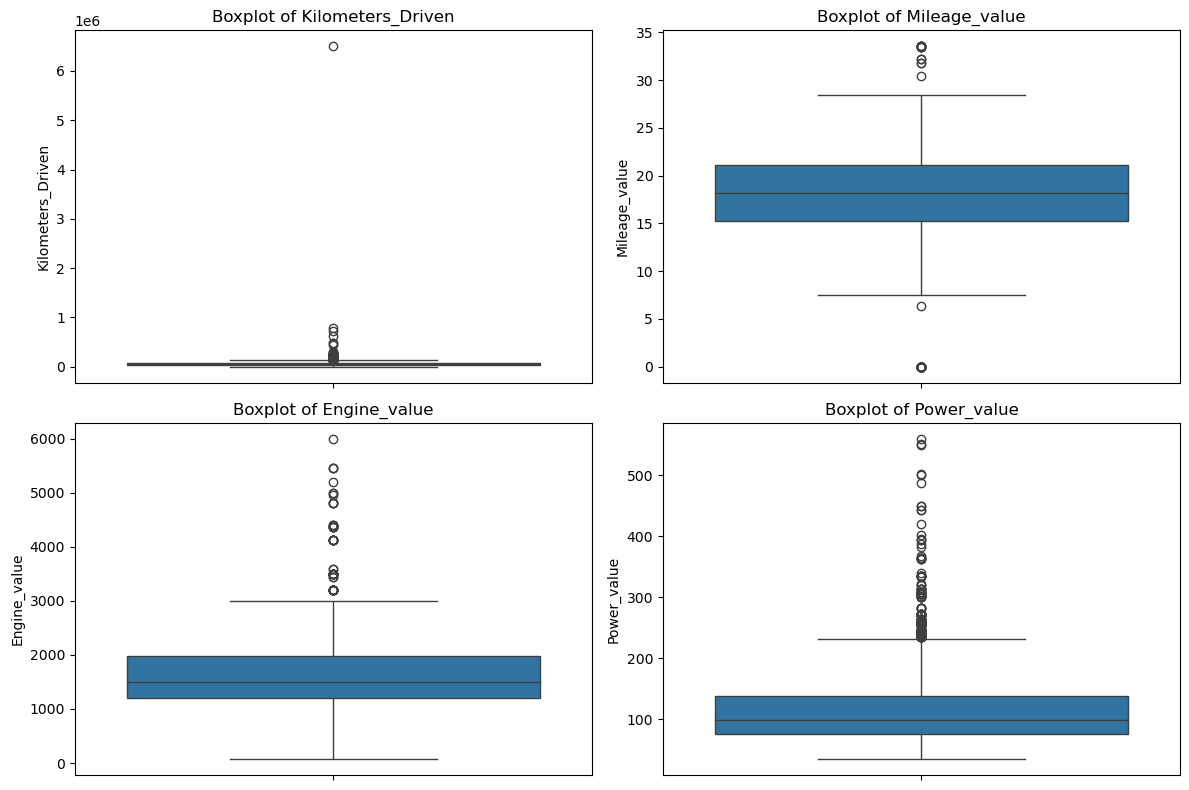

In [ ]:
plt.figure(figsize=(12,8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

* As, we can see there are outliers are there in all the numerical columns with the missing values.
* So, we fill them with the median.


In [ ]:
for i in df.columns:
    if i in num_cols:
        df[i].fillna(df[i].median(),inplace = True)

In [ ]:
df.isnull().sum()

Name                 0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Colour               0
Seats                0
No. of Doors         0
Price                0
Mileage_value        0
Mileage_unit         0
Engine_value         0
Engine_unit          0
Power_value          0
Power_unit           0
dtype: int64

#### Create car age feature to better explain price depreciation

In [ ]:
df['Car_Age'] = 2025 - df['Year']
df['Car_Age'] = df['Car_Age'].astype(int)
df.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Colour,Seats,No. of Doors,Price,Mileage_value,Mileage_unit,Engine_value,Engine_unit,Power_value,Power_unit,Car_Age
0,Mahindra Scorpio,Pune,2012.0,99000.0,Diesel,Manual,Third,Black/Silver,8.0,5.0,6.00,12.05,kmpl,2179.0,CC,120.0,bhp,13
1,Maruti Baleno,Kochi,2018.0,18678.0,Petrol,Manual,First,Others,5.0,4.0,8.32,21.10,kmpl,998.0,CC,100.0,bhp,7
2,Mahindra Xylo,Bangalore,2013.0,197000.0,Diesel,Manual,First,White,7.0,5.0,4.00,11.68,kmpl,2498.0,CC,112.0,bhp,12
3,Hyundai Grand,Delhi,2014.0,45000.0,Diesel,Manual,First,White,5.0,4.0,3.49,24.00,kmpl,1120.0,CC,70.0,bhp,11
4,Toyota Innova,Delhi,2011.0,65000.0,Diesel,Manual,First,Others,8.0,5.0,6.40,12.80,kmpl,2494.0,CC,102.0,bhp,14


#### Splitting the Name into Company Name & Model Name

In [ ]:
df[['Company_Name','Model_Name']] = df['Name'].str.rsplit(' ',n = 1,expand = True)
df.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Colour,Seats,No. of Doors,Price,Mileage_value,Mileage_unit,Engine_value,Engine_unit,Power_value,Power_unit,Car_Age,Company_Name,Model_Name
0,Mahindra Scorpio,Pune,2012.0,99000.0,Diesel,Manual,Third,Black/Silver,8.0,5.0,6.00,12.05,kmpl,2179.0,CC,120.0,bhp,13,Mahindra,Scorpio
1,Maruti Baleno,Kochi,2018.0,18678.0,Petrol,Manual,First,Others,5.0,4.0,8.32,21.10,kmpl,998.0,CC,100.0,bhp,7,Maruti,Baleno
2,Mahindra Xylo,Bangalore,2013.0,197000.0,Diesel,Manual,First,White,7.0,5.0,4.00,11.68,kmpl,2498.0,CC,112.0,bhp,12,Mahindra,Xylo
3,Hyundai Grand,Delhi,2014.0,45000.0,Diesel,Manual,First,White,5.0,4.0,3.49,24.00,kmpl,1120.0,CC,70.0,bhp,11,Hyundai,Grand
4,Toyota Innova,Delhi,2011.0,65000.0,Diesel,Manual,First,Others,8.0,5.0,6.40,12.80,kmpl,2494.0,CC,102.0,bhp,14,Toyota,Innova


## UNIVARIATE ANALYSIS

##### Top 5 Companies with the highest No. of Cars

In [ ]:
df.groupby('Company_Name')['Price'].sum().sort_values(ascending = False).head()

Company_Name
Mercedes-Benz    8525.54
BMW              6739.92
Audi             6026.90
Hyundai          5900.04
Maruti           5408.76
Name: Price, dtype: float64

In [ ]:
x = df.groupby('Company_Name')['Price'].sum().sort_values(ascending = False).head().index
y = df.groupby('Company_Name')['Price'].sum().sort_values(ascending = False).head().values

In [ ]:
x,y

(Index(['Mercedes-Benz', 'BMW', 'Audi', 'Hyundai', 'Maruti'], dtype='object', name='Company_Name'),
 array([8525.54, 6739.92, 6026.9 , 5900.04, 5408.76]))

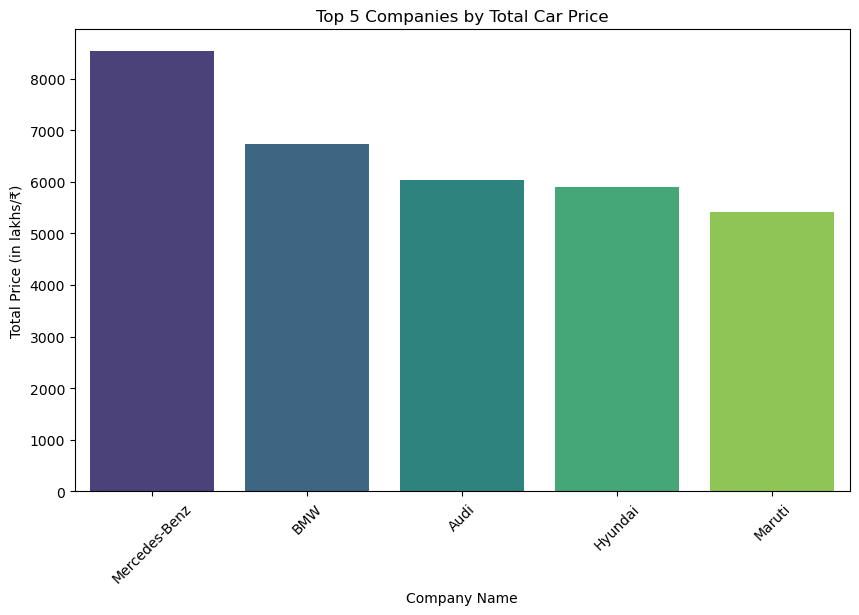

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=x, y=y, palette='viridis')
plt.title("Top 5 Companies by Total Car Price")
plt.ylabel("Total Price (in lakhs/₹)")
plt.xlabel("Company Name")
plt.xticks(rotation=45)
plt.show()


##### Top 5 cities with the Highest no of cars

In [ ]:
x = df['Location'].value_counts().head().index
y = df['Location'].value_counts().head().values
x,y


(Index(['Mumbai', 'Hyderabad', 'Kochi', 'Coimbatore', 'Pune'], dtype='object', name='Location'),
 array([792, 738, 646, 630, 611]))

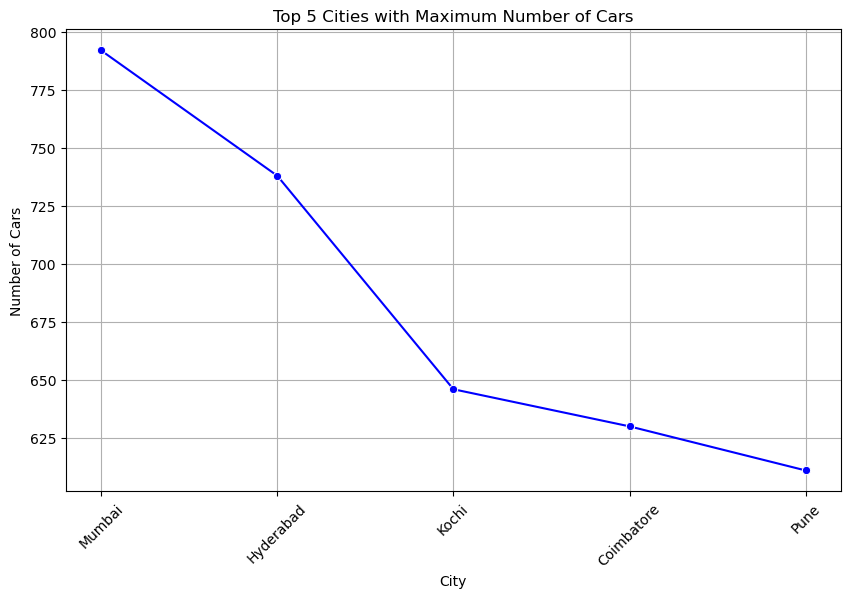

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(x = x,y = y, marker='o', color='blue')
plt.title("Top 5 Cities with Maximum Number of Cars")
plt.xlabel("City")
plt.ylabel("Number of Cars")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

##### Top 5 cities with the Minimum no of cars

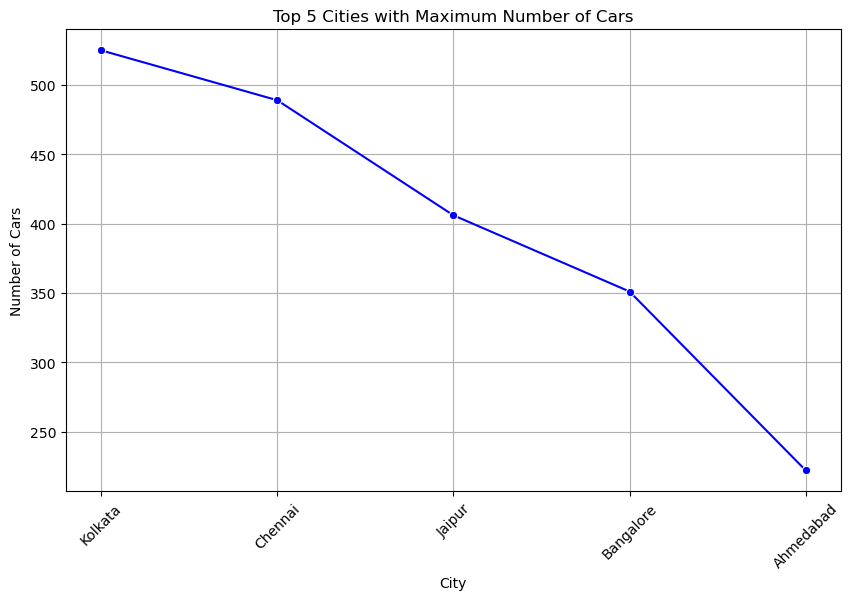

In [ ]:
x =df['Location'].value_counts().tail(5).index
y = df['Location'].value_counts().tail(5).values

plt.figure(figsize=(10,6))
sns.lineplot( x=x, y=y, marker='o', color='blue')
plt.title("Top 5 Cities with Maximum Number of Cars")
plt.xlabel("City")
plt.ylabel("Number of Cars")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

##### Year wise total no of cars

In [ ]:
df.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Colour,Seats,No. of Doors,Price,Mileage_value,Mileage_unit,Engine_value,Engine_unit,Power_value,Power_unit,Car_Age,Company_Name,Model_Name
0,Mahindra Scorpio,Pune,2012.0,99000.0,Diesel,Manual,Third,Black/Silver,8.0,5.0,6.00,12.05,kmpl,2179.0,CC,120.0,bhp,13,Mahindra,Scorpio
1,Maruti Baleno,Kochi,2018.0,18678.0,Petrol,Manual,First,Others,5.0,4.0,8.32,21.10,kmpl,998.0,CC,100.0,bhp,7,Maruti,Baleno
2,Mahindra Xylo,Bangalore,2013.0,197000.0,Diesel,Manual,First,White,7.0,5.0,4.00,11.68,kmpl,2498.0,CC,112.0,bhp,12,Mahindra,Xylo
3,Hyundai Grand,Delhi,2014.0,45000.0,Diesel,Manual,First,White,5.0,4.0,3.49,24.00,kmpl,1120.0,CC,70.0,bhp,11,Hyundai,Grand
4,Toyota Innova,Delhi,2011.0,65000.0,Diesel,Manual,First,Others,8.0,5.0,6.40,12.80,kmpl,2494.0,CC,102.0,bhp,14,Toyota,Innova
